In [11]:
# load th necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore') # ignoring warnings for a clean notebook

In [14]:
# loading the dataset
df = pd.read_csv("C:/Users/SamuelAster Agondeze/Downloads/ds assessment/iSDA_soil_data.csv")
print(df.shape)
df.head()
df.info()
df.describe()

(49225, 24)
<class 'pandas.DataFrame'>
RangeIndex: 49225 entries, 0 to 49224
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   longitude                49225 non-null  float64
 1   latitude                 49225 non-null  float64
 2   start_date               49225 non-null  str    
 3   end_date                 49225 non-null  str    
 4   source                   49225 non-null  str    
 5   horizon_lower            49225 non-null  int64  
 6   horizon_upper            49225 non-null  int64  
 7   aluminium_extractable    49223 non-null  float64
 8   boron_extractable        2111 non-null   float64
 9   calcium_extractable      49225 non-null  float64
 10  carbon_organic           49225 non-null  float64
 11  carbon_total             47068 non-null  float64
 12  copper_extractable       49179 non-null  float64
 13  electrical_conductivity  2109 non-null   float64
 14  iron_extractable     

,longitude,latitude,horizon_lower,horizon_upper,aluminium_extractable,boron_extractable,calcium_extractable,carbon_organic,carbon_total,copper_extractable,...,iron_extractable,magnesium_extractable,manganese_extractable,nitrogen_total,ph,phosphorus_extractable,potassium_extractable,sodium_extractable,sulphur_extractable,zinc_extractable
count,49225.000000,49225.000000,49225.000000,49225.000000,49223.000000,2111.000000,49225.000000,49225.000000,47068.000000,49179.000000,...,49179.000000,49225.000000,49177.000000,49179.000000,49222.000000,2111.000000,49225.000000,2155.000000,2111.000000,2111.000000
mean,26.308297,-4.242106,33.709497,9.139665,801.726081,0.067028,1891.832490,12.700874,13.514089,2.253515,...,109.898127,361.500007,126.477587,0.977086,6.401090,6.226770,245.880751,37.937608,7.765493,1.256226
std,14.677322,9.450069,14.944535,9.963024,309.794014,0.072169,2590.703064,9.852421,9.969849,1.451125,...,42.406047,350.892043,67.298766,0.763400,0.875862,4.660828,227.736808,18.839473,3.646372,0.385302
min,-13.433100,-29.981300,20.000000,0.000000,21.800000,0.001611,3.497000,1.070000,1.490000,0.001000,...,14.247000,4.995000,0.023000,0.060000,2.270000,0.898422,2.926050,0.564734,2.693880,0.410652
25%,22.038500,-8.906570,20.000000,0.000000,583.782500,0.020293,554.539000,6.590000,7.090000,1.082000,...,82.717000,141.472000,77.027000,0.510000,5.854440,3.391750,101.853000,26.438800,5.537305,0.975863
50%,33.610260,-5.365800,20.000000,0.000000,741.250000,0.044616,997.386000,9.930000,10.700000,2.052920,...,102.492000,235.280000,118.847000,0.770000,6.260000,4.978020,177.280000,33.409700,6.874680,1.225570
75%,35.220230,1.464150,50.000000,20.000000,972.251000,0.089173,2016.999000,15.270000,16.170000,3.156000,...,129.295000,445.134000,167.463000,1.170000,6.756000,7.599695,309.188000,44.603300,8.896170,1.489725
max,48.763800,14.886790,50.000000,20.000000,2514.834000,0.705266,32376.666000,310.000000,86.010000,19.831000,...,497.900000,4485.197000,1016.893000,15.900000,9.914000,83.700000,3830.490000,232.143000,44.533500,2.771600


1.Data Cleaning

In [17]:
# checking for duplicates
df.duplicated().sum()

np.int64(42)

In [19]:
# droping duplicates
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [23]:
# checking the data again
df.head()

,longitude,latitude,horizon_lower,horizon_upper,aluminium_extractable,boron_extractable,calcium_extractable,carbon_organic,carbon_total,copper_extractable,...,iron_extractable,magnesium_extractable,manganese_extractable,nitrogen_total,ph,phosphorus_extractable,potassium_extractable,sodium_extractable,sulphur_extractable,zinc_extractable
0,35.18756,-8.62390,50,20,1109.856,NaN,1535.388,30.66,31.50,2.259,...,92.366,200.601,107.257,2.24,5.942,NaN,283.103,NaN,NaN,NaN
1,35.18558,-8.62300,50,20,1168.364,NaN,751.408,21.15,19.36,1.822,...,115.923,197.771,90.005,1.57,5.722,NaN,215.459,NaN,NaN,NaN
2,35.18579,-8.62221,50,20,1137.113,NaN,468.391,15.64,13.95,1.913,...,78.709,188.114,120.433,1.02,5.510,NaN,398.656,NaN,NaN,NaN
3,35.18266,-8.62177,50,20,1117.349,NaN,739.698,15.63,12.32,2.876,...,127.527,156.417,112.036,1.12,5.817,NaN,267.354,NaN,NaN,NaN
4,35.12984,-8.62005,50,20,1219.203,NaN,240.071,18.49,17.34,1.825,...,77.542,114.809,57.906,1.19,4.980,NaN,229.682,NaN,NaN,NaN


In [28]:
# dropping stucturally missing columns/missing data especially wetchem related
missing_cols = ['boron_extractable', 'electrical_conductivity', 'phosphorus_extractable', 'sodium_extractable', 'sulphur_extractable',
                'zinc_extractable']
df.drop(columns=missing_cols, inplace=True)
df.info()
df.head()

<class 'pandas.DataFrame'>
Index: 49183 entries, 0 to 49224
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   longitude              49183 non-null  float64
 1   latitude               49183 non-null  float64
 2   horizon_lower          49183 non-null  int64  
 3   horizon_upper          49183 non-null  int64  
 4   aluminium_extractable  49181 non-null  float64
 5   calcium_extractable    49183 non-null  float64
 6   carbon_organic         49183 non-null  float64
 7   carbon_total           47026 non-null  float64
 8   copper_extractable     49137 non-null  float64
 9   iron_extractable       49137 non-null  float64
 10  magnesium_extractable  49183 non-null  float64
 11  manganese_extractable  49135 non-null  float64
 12  nitrogen_total         49137 non-null  float64
 13  ph                     49180 non-null  float64
 14  potassium_extractable  49183 non-null  float64
dtypes: float64(13), in

,longitude,latitude,horizon_lower,horizon_upper,aluminium_extractable,calcium_extractable,carbon_organic,carbon_total,copper_extractable,iron_extractable,magnesium_extractable,manganese_extractable,nitrogen_total,ph,potassium_extractable
0,35.18756,-8.62390,50,20,1109.856,1535.388,30.66,31.50,2.259,92.366,200.601,107.257,2.24,5.942,283.103
1,35.18558,-8.62300,50,20,1168.364,751.408,21.15,19.36,1.822,115.923,197.771,90.005,1.57,5.722,215.459
2,35.18579,-8.62221,50,20,1137.113,468.391,15.64,13.95,1.913,78.709,188.114,120.433,1.02,5.510,398.656
3,35.18266,-8.62177,50,20,1117.349,739.698,15.63,12.32,2.876,127.527,156.417,112.036,1.12,5.817,267.354
4,35.12984,-8.62005,50,20,1219.203,240.071,18.49,17.34,1.825,77.542,114.809,57.906,1.19,4.980,229.682


In [32]:
# handling carbon_total gaps by imputing and droping remaining nulls
df['carbon_total'].fillna(df['carbon_total'].median(), inplace=True)
df.dropna(inplace=True)
print(df.shape)
print(df.isnull().sum())
df.head()

(47023, 15)
longitude                0
latitude                 0
horizon_lower            0
horizon_upper            0
aluminium_extractable    0
calcium_extractable      0
carbon_organic           0
carbon_total             0
copper_extractable       0
iron_extractable         0
magnesium_extractable    0
manganese_extractable    0
nitrogen_total           0
ph                       0
potassium_extractable    0
dtype: int64


,longitude,latitude,horizon_lower,horizon_upper,aluminium_extractable,calcium_extractable,carbon_organic,carbon_total,copper_extractable,iron_extractable,magnesium_extractable,manganese_extractable,nitrogen_total,ph,potassium_extractable
0,35.18756,-8.62390,50,20,1109.856,1535.388,30.66,31.50,2.259,92.366,200.601,107.257,2.24,5.942,283.103
1,35.18558,-8.62300,50,20,1168.364,751.408,21.15,19.36,1.822,115.923,197.771,90.005,1.57,5.722,215.459
2,35.18579,-8.62221,50,20,1137.113,468.391,15.64,13.95,1.913,78.709,188.114,120.433,1.02,5.510,398.656
3,35.18266,-8.62177,50,20,1117.349,739.698,15.63,12.32,2.876,127.527,156.417,112.036,1.12,5.817,267.354
4,35.12984,-8.62005,50,20,1219.203,240.071,18.49,17.34,1.825,77.542,114.809,57.906,1.19,4.980,229.682


In [37]:
# coding horizon depth as one categorical column
df['horizon'] = df['horizon_upper'].apply(lambda x: 'topsoil' if x == 0 else 'subsoil')
df.drop(columns=['horizon_upper', 'horizon_lower'], inplace=True)
df['horizon'].value_counts()

horizon
topsoil    24570
subsoil    22453
Name: count, dtype: int64

In [36]:
df.head()

,longitude,latitude,aluminium_extractable,calcium_extractable,carbon_organic,carbon_total,copper_extractable,iron_extractable,magnesium_extractable,manganese_extractable,nitrogen_total,ph,potassium_extractable,horizon
0,35.18756,-8.62390,1109.856,1535.388,30.66,31.50,2.259,92.366,200.601,107.257,2.24,5.942,283.103,subsoil
1,35.18558,-8.62300,1168.364,751.408,21.15,19.36,1.822,115.923,197.771,90.005,1.57,5.722,215.459,subsoil
2,35.18579,-8.62221,1137.113,468.391,15.64,13.95,1.913,78.709,188.114,120.433,1.02,5.510,398.656,subsoil
3,35.18266,-8.62177,1117.349,739.698,15.63,12.32,2.876,127.527,156.417,112.036,1.12,5.817,267.354,subsoil
4,35.12984,-8.62005,1219.203,240.071,18.49,17.34,1.825,77.542,114.809,57.906,1.19,4.980,229.682,subsoil


In [38]:
# detecting and capping outliers using interquartile range(IQR) method
def cap_outliers(df, col):
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)
    return df

for col in ['carbon_organic', 'calcium_extractable', 'aluminium_extractable',
            'potassium_extractable', 'magnesium_extractable']:
    df = cap_outliers(df, col)

df.describe()

,longitude,latitude,aluminium_extractable,calcium_extractable,carbon_organic,carbon_total,copper_extractable,iron_extractable,magnesium_extractable,manganese_extractable,nitrogen_total,ph,potassium_extractable
count,47023.000000,47023.000000,47023.000000,47023.000000,47023.000000,47023.000000,47023.000000,47023.000000,47023.000000,47023.000000,47023.000000,47023.000000,47023.000000
mean,27.131958,-4.867292,806.076633,1540.038211,12.076671,13.512113,2.311673,108.727472,338.327672,129.464566,0.991897,6.418949,234.278284
std,14.453965,9.163869,297.308423,1303.058232,7.065464,9.964093,1.450162,41.911319,255.541069,66.970092,0.772929,0.885977,163.838091
min,-13.433100,-29.981300,51.850000,3.497000,1.740000,1.490000,0.001000,14.247000,4.995000,0.023000,0.060000,3.354000,9.850000
25%,26.503700,-9.010610,590.826000,573.111500,6.690000,7.090000,1.149000,82.201500,144.899000,80.892750,0.520000,5.863000,105.819500
50%,33.827360,-5.952590,748.319000,1032.732000,10.100000,10.700000,2.129000,101.493000,242.174000,122.102000,0.790000,6.277000,184.778000
75%,35.317865,-1.789265,982.146500,2085.033500,15.540000,16.170000,3.215000,127.291000,457.466500,169.942500,1.190000,6.787000,316.899000
max,48.763800,14.886790,1569.127250,4352.916500,28.815000,86.010000,19.831000,493.454000,926.317750,1016.893000,15.900000,9.914000,633.518250


In [39]:
df.head()

,longitude,latitude,aluminium_extractable,calcium_extractable,carbon_organic,carbon_total,copper_extractable,iron_extractable,magnesium_extractable,manganese_extractable,nitrogen_total,ph,potassium_extractable,horizon
0,35.18756,-8.62390,1109.856,1535.388,28.815,31.50,2.259,92.366,200.601,107.257,2.24,5.942,283.103,subsoil
1,35.18558,-8.62300,1168.364,751.408,21.150,19.36,1.822,115.923,197.771,90.005,1.57,5.722,215.459,subsoil
2,35.18579,-8.62221,1137.113,468.391,15.640,13.95,1.913,78.709,188.114,120.433,1.02,5.510,398.656,subsoil
3,35.18266,-8.62177,1117.349,739.698,15.630,12.32,2.876,127.527,156.417,112.036,1.12,5.817,267.354,subsoil
4,35.12984,-8.62005,1219.203,240.071,18.490,17.34,1.825,77.542,114.809,57.906,1.19,4.980,229.682,subsoil


In [40]:
# exporting the cleaned dataset to a CSV file
df.to_csv('cleaned_dataset.csv', index=False)

2.Exploratory Data Analysis

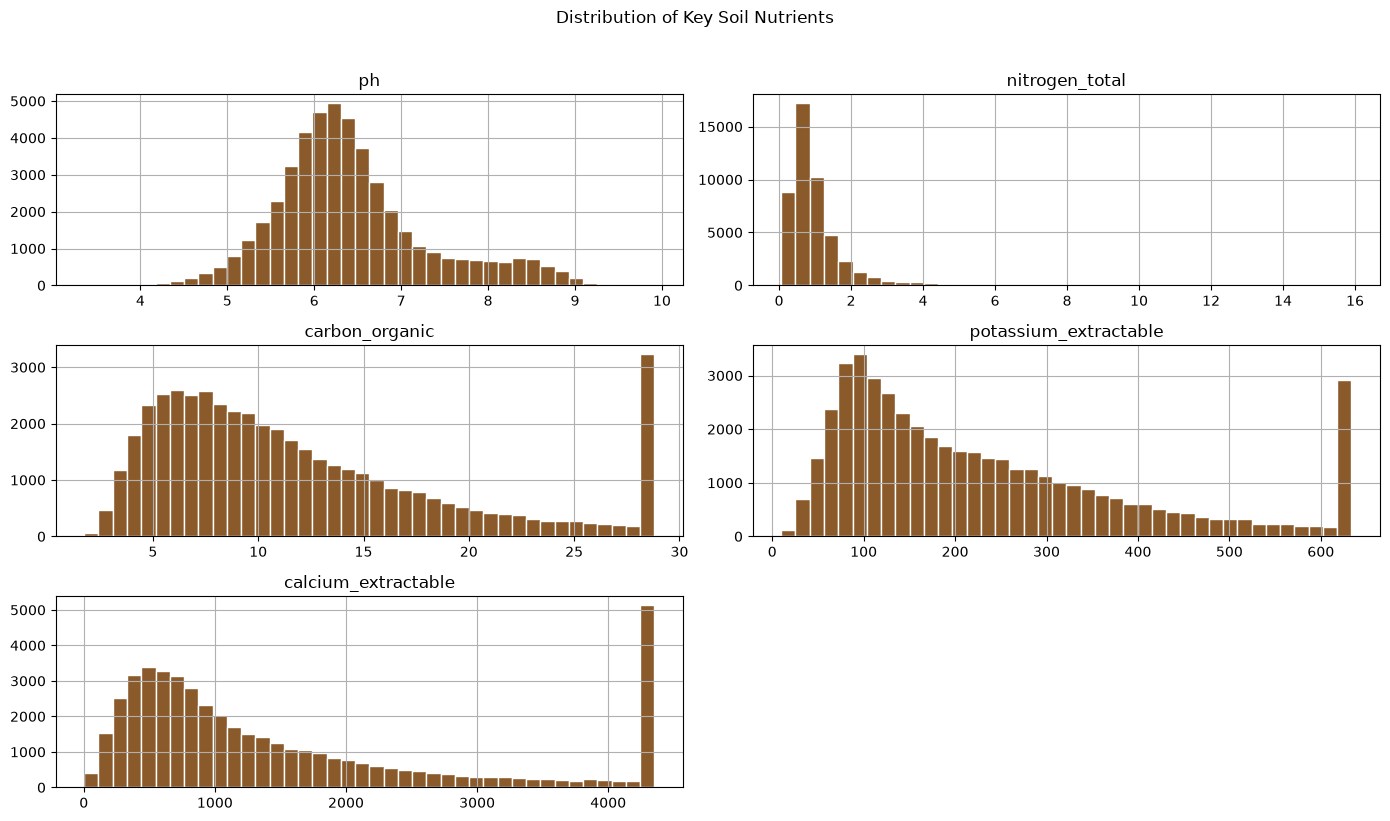

In [42]:
# 1. distribution of Key Soil Nutrients
cols = ['ph', 'nitrogen_total', 'carbon_organic', 'potassium_extractable', 'calcium_extractable']

df[cols].hist(bins=40, figsize=(14, 8), color='#8B5A2B', edgecolor='white')
plt.suptitle('Distribution of Key Soil Nutrients', y=1.02)
plt.tight_layout()
plt.show()

Key Insight: Most of the key nutrients are right-skewed. This means that a few very high readings or records pull the mean above the median. pH, however, shows an almost normal distribution, while Organic Carbon by combustion after acidification, Potassium, Mehlich3 extraction, and Calcium, Mehlich3 extraction show notable outliers to the right. 

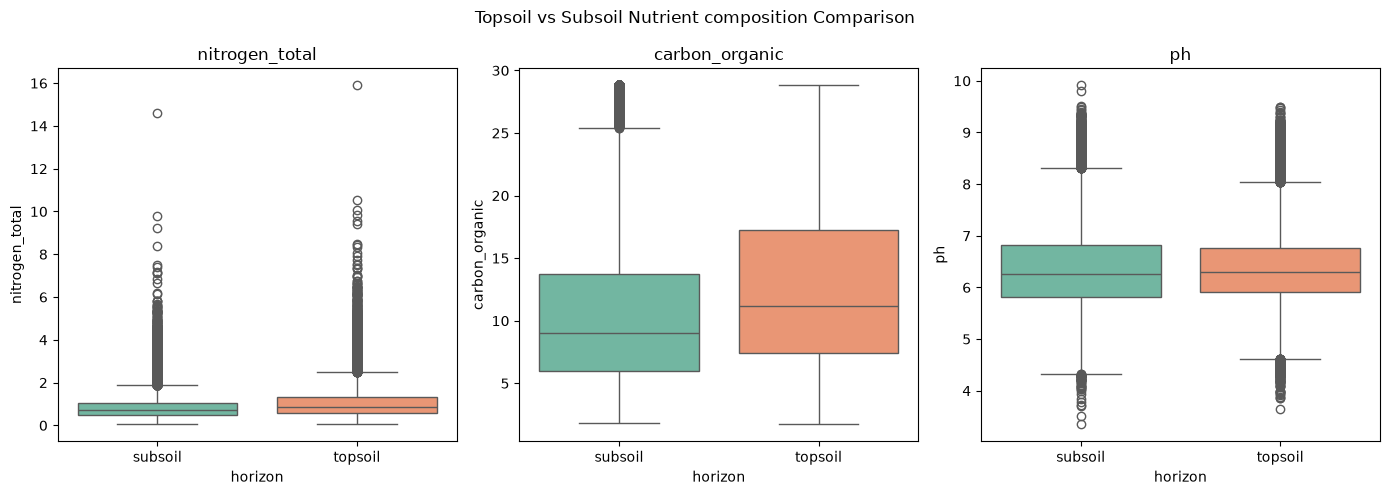

In [44]:
# 2. Top soil vs Sub soil for Nutrient comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col in zip(axes, ['nitrogen_total', 'carbon_organic', 'ph']):
    sns.boxplot(data=df, x='horizon', y=col, ax=ax, palette='Set2')
    ax.set_title(col)

plt.suptitle('Topsoil vs Subsoil Nutrient composition Comparison')
plt.tight_layout()
plt.show()

Key Insight: Top soil has higher Nitrogen total and Organic carborn which validates that organic matter is concentrated at the surface or the top more than i the subsoil layer. While the pH is almost the same for both depths, subsoil has a slightky higher pH. 

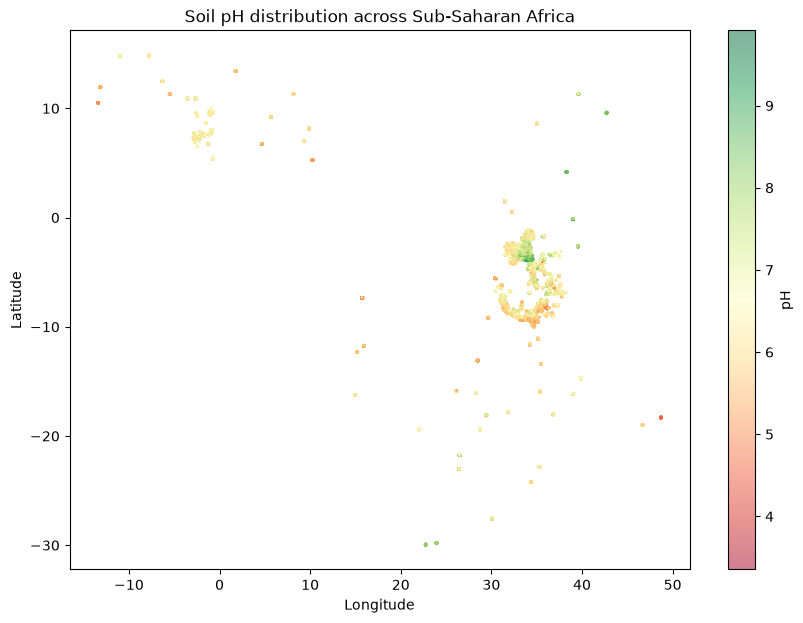

In [47]:
# 3. Geographical distribution of pH with map 
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df['longitude'], df['latitude'], c=df['ph'],
                      cmap='RdYlGn', s=1, alpha=0.5)
plt.colorbar(scatter, label='pH')
plt.title('Soil pH distribution across Sub-Saharan Africa')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

Key Insight: Acidic soil sites cluster in the equatorial belt of East and West Africa near the equator, while alkaline soil sites cluster in the horn of Africa and southern Africa tip. East Africa has a dense mix of acidic and alkaline soil sites, likely the most sampled area. 

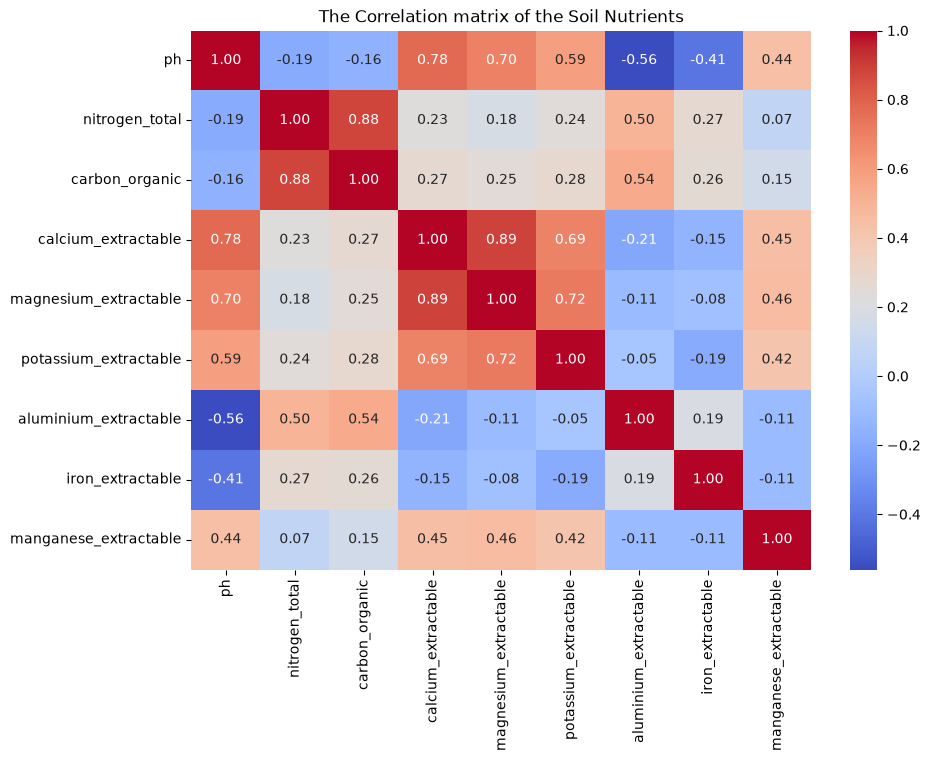

In [49]:
# 4. The Correlation Heatmap of the nutrients
corr_columns = ['ph', 'nitrogen_total', 'carbon_organic', 'calcium_extractable',
             'magnesium_extractable', 'potassium_extractable', 'aluminium_extractable',
             'iron_extractable', 'manganese_extractable']

plt.figure(figsize=(10, 7))
sns.heatmap(df[corr_columns].corr().round(2), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('The Correlation matrix of the Soil Nutrients')
plt.show()

Key insights: More organic matter implies more of carbon and Nitrogen explained by the high positive correlation (0.88) of carbon and Nitrogen. 
Calcium and Magnesium share the same geological source and so ted to move together hence their positive correlation (0.89). The high correlation between calcium and pH (0.78) could as a result of the formation of calcium carbonates in the soiul which tend to be acidic in nature.

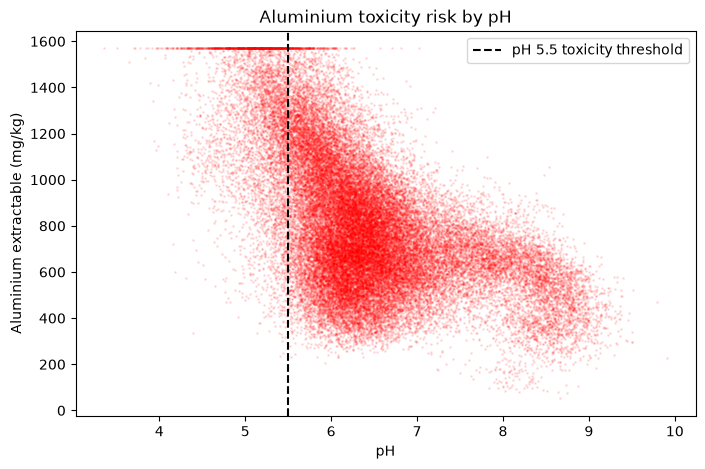

In [53]:
# 5. Toxicity risk (alumunium vs pH)
plt.figure(figsize=(8, 5))
plt.scatter(df['ph'], df['aluminium_extractable'], alpha=0.1, s=1, color='red')
plt.axvline(x=5.5, color='black', linestyle='--', label='pH 5.5 toxicity threshold')
plt.xlabel('pH')
plt.ylabel('Aluminium extractable (mg/kg)')
plt.title('Aluminium toxicity risk by pH')
plt.legend()
plt.show()

Key insight: Alumunium levels are high in pH zones below 5.5 which means that soil sites in this zone pose alumunium toxicity risk for sensitive crops. 

3.Feature Engineering

In [58]:
# 1. Soil Organic Matter 
# soil orgaing matter formula: organic carbon*1.724 (standard Van Bemmelen factor)
df['soil_organic_matter'] = df['carbon_organic'] * 1.724
df['soil_organic_matter'].value_counts()

soil_organic_matter
49.67706    3047
12.60244      53
9.27512       52
13.25756      51
12.36108      51
            ... 
10.92154       1
12.86966       1
35.54026       1
24.85146       1
12.49038       1
Name: count, Length: 3472, dtype: int64

In [56]:
# 2. Flagging soils for alumunium toxicity (alumunium toxicity flag)
df['alum_toxicity_flag'] = ((df['aluminium_extractable'] > 1000) & (df['ph'] < 5.5)).astype(int)
df['alum_toxicity_flag'].value_counts()

alum_toxicity_flag
0    42968
1     4055
Name: count, dtype: int64

In [61]:
# 3. Binary coding the horizon for better weighting in recommendation system
df['is_topsoil'] = (df['horizon'] == 'topsoil').astype(int)
df['is_topsoil'].value_counts()

is_topsoil
1    24570
0    22453
Name: count, dtype: int64

4.Recommendation Logic

In [63]:
# what crops are recommended for a soil site depending on its soil sample properties and features? 
# what crops are recommended for a region depending on its soil sample average properties?

# Step 1: Create the crop threshold reference table (soil sample characteristics that favour a give crop based on its thriving requrements)
crop_rules = {
    'Maize':      {'ph': (5.5, 7.5), 'nitrogen_total': 0.8, 'potassium_extractable': 80,  'aluminium_extractable': 500},
    'Cassava':    {'ph': (4.5, 7.0), 'nitrogen_total': 0.5, 'potassium_extractable': 60,  'aluminium_extractable': 800},
    'Sorghum':    {'ph': (5.5, 8.0), 'nitrogen_total': 0.6, 'potassium_extractable': 70,  'aluminium_extractable': 600},
    'Groundnuts': {'ph': (5.0, 7.0), 'nitrogen_total': 0.4, 'potassium_extractable': 50,  'aluminium_extractable': 700},
    'Beans':      {'ph': (6.0, 7.5), 'nitrogen_total': 0.7, 'potassium_extractable': 80,  'aluminium_extractable': 400},
}

In [65]:
# building the scoring criteria function
def crop_recommender(soil):
    scores = {}
    for crop, rules in crop_rules.items():
        score = 0
        if rules['ph'][0] <= soil['ph'] <= rules['ph'][1]: score += 1
        if soil['nitrogen_total'] >= rules['nitrogen_total']:         score += 1
        if soil['potassium_extractable'] >= rules['potassium_extractable']: score += 1
        if soil['aluminium_extractable'] <= rules['aluminium_extractable']: score += 1
        scores[crop] = score
    best = max(scores, key=scores.get)
    return best, scores

In [75]:
# testing the recommendor with a sample
sample = {
    'ph': 5.3,
    'nitrogen_total': 0.6,
    'potassium_extractable': 95,
    'aluminium_extractable': 620
}

crop, scores = crop_recommender(sample)
print(f"Recommended crop: {crop}")
print(f"Scores: {scores}")

Recommended crop: Cassava
Scores: {'Maize': 1, 'Cassava': 4, 'Sorghum': 2, 'Groundnuts': 4, 'Beans': 1}
